### LASSO回归

In [397]:
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

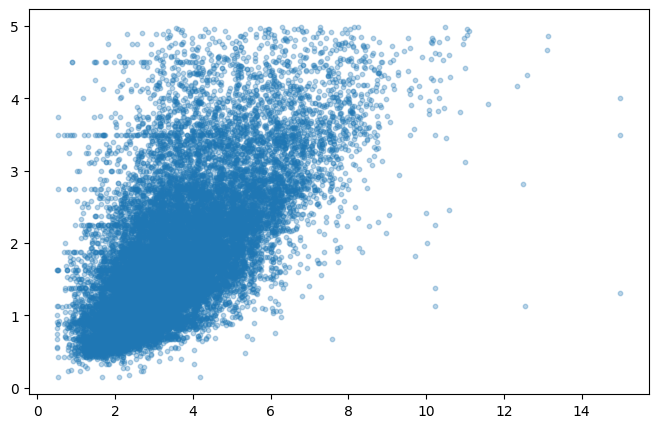

In [398]:
housing = fetch_california_housing()
X = housing.data[:, 0].reshape(-1, 1)  # 选择MedInc作为唯一特征,并且将一维数据转换为二维特征矩阵
y = housing.target  # 房价中位数作为目标值
X = X[y < 5]  # 删除目标值大于等于 5 的样本，减少房价上限截断对回归模型的影响
y = y[y < 5]  # 使用相同条件过滤目标值，保证 X 和 y 的样本一一对应
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.3, s=10)
plt.show()

In [399]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=233, shuffle=True)

In [400]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
def PolynomialRegression(degree):  # 创建多项式回归流水线
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),  # 生成多项式特征
        ("std_scaler", StandardScaler()),             # 标准化特征
        ("lin_reg", LinearRegression())])             # 线性回归模型

In [401]:
poly_reg = PolynomialRegression(degree=20)   # 创建20阶多项式回归模型
poly_reg.fit(X_train, y_train);              # 使用训练数据训练模型

In [402]:
from sklearn.metrics import mean_squared_error  # 导入均方误差 MSE
y_predict = poly_reg.predict(X_test)            # 使用模型预测测试集
mean_squared_error(y_test, y_predict)           # 计算测试集的 MSE

0.5447941548937738

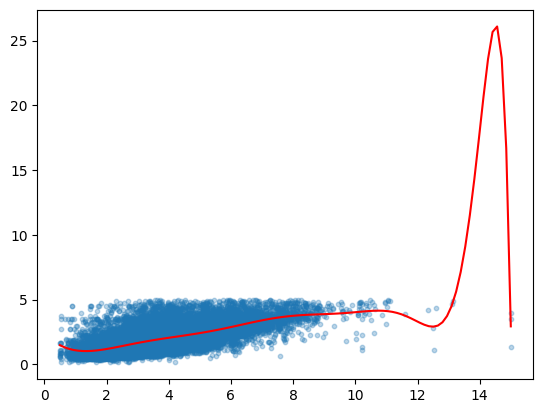

In [403]:
def show_plot(model):
    plt.scatter(X, y, alpha=0.3, s=10)  # 绘制原始数据散点图
    X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)  # 根据 X 的实际范围生成 100 个连续点
    y_plot = model.predict(X_plot)  # 使用模型预测 y 值
    plt.plot(X_plot[:, 0], y_plot, color="red")  # 绘制回归曲线
    plt.show()
show_plot(poly_reg)  # 绘制多项式回归结果

In [404]:
from sklearn.linear_model import Lasso  # 导入 Lasso 回归模型
def LassoRegression(degree, alpha):  # 创建 Lasso 多项式回归流水线
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),    # 生成多项式特征
        ("std_scaler", StandardScaler()),               # 标准化特征
        ("lasso_reg", Lasso(alpha=alpha))])             # Lasso 回归，alpha 控制正则化强度

In [405]:
lasso_reg = LassoRegression(20, 0.0001)           # 创建20阶 Lasso 回归模型
lasso_reg.fit(X_train, y_train)                   # 使用训练集训练模型
y_predict = lasso_reg.predict(X_test)             # 预测测试集
mean_squared_error(y_test, y_predict)             # 计算测试集 MSE

0.5485711242517479

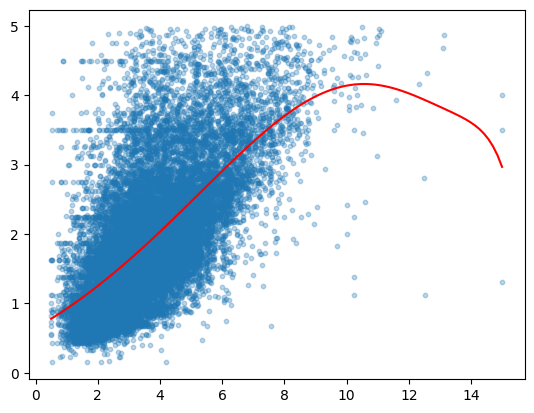

In [406]:
show_plot(lasso_reg)

### Ridge回归

In [407]:
from sklearn.linear_model import Ridge  # 导入岭回归模型
def RidgeRegression(degree, alpha):     # 创建岭回归多项式流水线
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),    # 生成多项式特征
        ("std_scaler", StandardScaler()),               # 标准化特征
        ("ridge_reg", Ridge(alpha=alpha))])             # 岭回归，alpha 控制正则化强度

In [408]:
ridge_reg = RidgeRegression(20, 100)                 # 创建20阶岭回归模型
ridge_reg.fit(X_train, y_train)                      # 使用训练集训练模型
y_predict = ridge_reg.predict(X_test)                # 预测测试集
mean_squared_error(y_test, y_predict)                # 计算测试集 MSE

0.5485090696777729

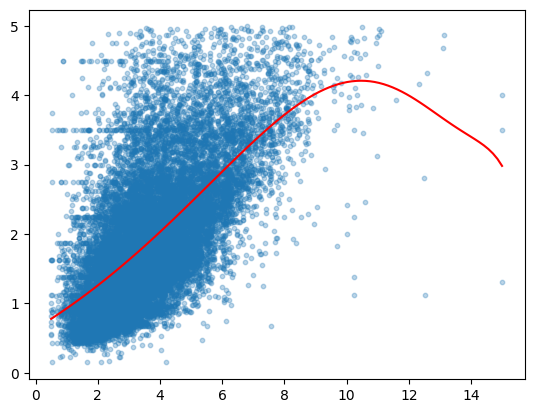

In [409]:
show_plot(ridge_reg)